In [1]:
import numpy as np
import matplotlib.pyplot as plt
# %matplotlib Tk

## Triads

In [27]:
kmax=30;kmin=6
n=int(kmax)*2+1
idk=(np.array(np.where(np.zeros([n]*2)==0))-kmax).astype(int)
order=lambda x: ((x[0]+kmax)*n+(x[1]+kmax)).astype(int)

In [29]:
%%time

k=[];p=[];q=[]

for i in range(len(idk.T)):
    tmp1=(np.linalg.norm(idk.T[i].reshape(2,1),axis=0)<=kmax) & (np.linalg.norm(idk,axis=0)<=kmax) & (np.linalg.norm(-idk-idk.T[i].reshape(2,1),axis=0)<=kmax)
    tmp2=(np.linalg.norm(idk.T[i].reshape(2,1),axis=0)>=kmin) & (np.linalg.norm(idk,axis=0)>=kmin) & (np.linalg.norm(-idk-idk.T[i].reshape(2,1),axis=0)>=kmin)
    tmp3=(order(idk.T[i])<order(idk)) & (order(idk)<order(-idk-idk.T[i].reshape(2,1)))
    if (tmp1&tmp2&tmp3).sum()!=0:
        k.append(np.array([idk.T[i]]*(tmp1&tmp2&tmp3).sum()))
        tmp=idk.T[tmp1&tmp2&tmp3]
        p.append(tmp)
        q.append(-tmp-idk.T[i])

k=np.row_stack(k).T;p=np.row_stack(p).T;q=np.row_stack(q).T
kmag=np.linalg.norm(k,axis=0)**2
pmag=np.linalg.norm(p,axis=0)**2
qmag=np.linalg.norm(q,axis=0)**2

CPU times: user 529 ms, sys: 242 ms, total: 772 ms
Wall time: 771 ms


In [5]:
A=np.zeros([len(idk.T)]*2);G=np.zeros([len(idk.T)]*2)
A[order(k),order(p)]=1
A[order(k),order(q)]=1
A[order(p),order(q)]=1
A=A+A.T

G[order(k),order(p)]=(kmag**2)*np.cross(q,p,axis=0)
G[order(k),order(q)]=(kmag**2)*np.cross(p,q,axis=0)
G[order(p),order(k)]=(pmag**2)*np.cross(q,k,axis=0)
G[order(p),order(q)]=(pmag**2)*np.cross(k,q,axis=0)
G[order(q),order(k)]=(qmag**2)*np.cross(p,k,axis=0)
G[order(q),order(p)]=(qmag**2)*np.cross(k,p,axis=0)

## Plots

In [7]:
counts=np.unique(np.column_stack((k,p,q)),axis=1,return_counts=True)

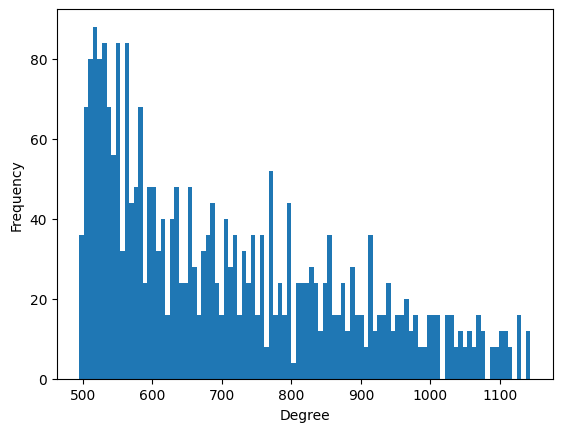

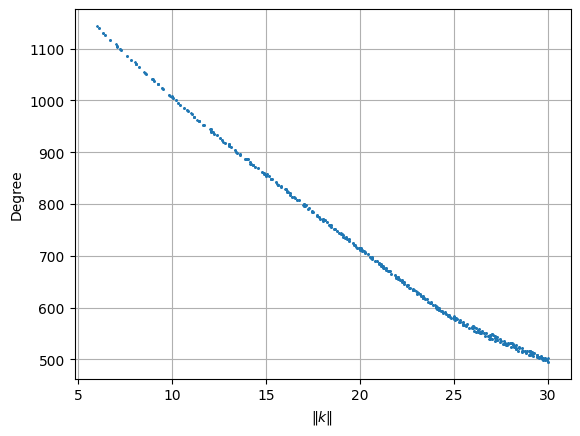

In [8]:
# plt.hist(counts[1],bins=100)
# plt.show()
plt.hist(A[order(counts[0]).astype(int)].sum(axis=1)/2,bins=100)
plt.xlabel('Degree');plt.ylabel('Frequency')
plt.show()

plt.plot(np.linalg.norm(counts[0],axis=0),A[order(counts[0]).astype(int)].sum(axis=1)/2,'.',ms=1)
plt.grid()
plt.xlabel(r'$\|k\|$');plt.ylabel('Degree')
plt.show()

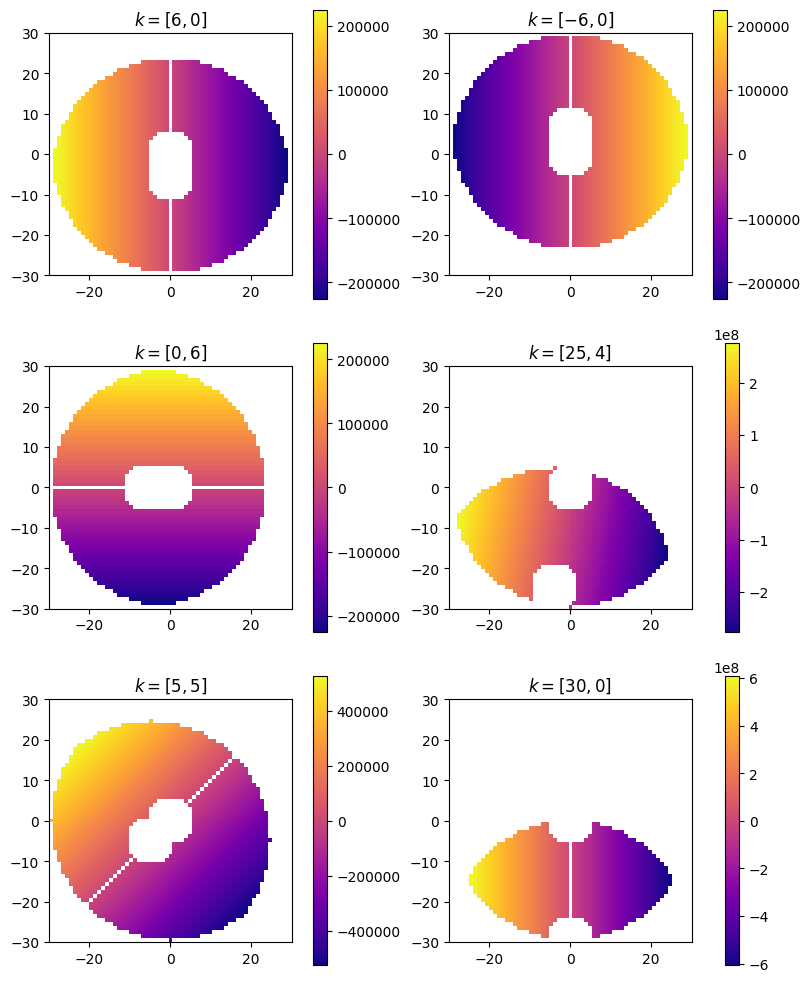

In [9]:
fig,ax=plt.subplots(3,2,layout='constrained',figsize=(8,10))

points=[np.array([6,0]),np.array([-6,0]),np.array([0,6]),np.array([25,4]),np.array([5,5]),np.array([30,0])]
coords=(idk+kmax).astype(int)

for i in range(len(points)):
    grid=np.zeros([n]*2)
    grid[coords[0],coords[1]]=G[order(points[i])]
    grid[grid==0]=None
    ax.flat[i].set_title(rf'$k=[{points[i][0]}, {points[i][1]}]$')
    ax.flat[i].imshow(grid,extent=[-kmax,kmax,-kmax,kmax],origin='lower',cmap='plasma')
    plt.colorbar(ax.flat[i].imshow(grid,extent=[-kmax,kmax,-kmax,kmax],origin='lower',cmap='plasma'))    
plt.show()

## Old version (slower and more memory)

In [31]:
# def get_triads(dk=1,kmax=2,kmin=0):
#     if int(kmax/dk)!=kmax/dk:
#         print('kmax must divide evenly by dk')
#         return
        
#     n=int(kmax/dk)*2+1
#     A=np.zeros([n]*4)
#     # G=np.zeros(A.shape)
#     idx=dk*(np.array(np.where(A==0))-(kmax/dk)).astype(int)
    
#     tmp1=((-idx[0]-idx[2])**2+(-idx[1]-idx[3])**2<=kmax**2) & (idx[0]**2+idx[1]**2<=kmax**2) & (idx[2]**2+idx[3]**2<=kmax**2) & ~((idx[0]==idx[2])&(idx[1]==idx[3]))
#     tmp2=((-idx[0]-idx[2])**2+(-idx[1]-idx[3])**2>=kmin**2) & (idx[0]**2+idx[1]**2>=kmin**2) & (idx[2]**2+idx[3]**2>=kmin**2)
#     triads=idx[:,tmp1&tmp2]
    
#     k=triads[[0,1]]
#     p=triads[[2,3]]
#     q=-triads[[0,1]]-triads[[2,3]]
    
#     # grid=np.zeros([n]*2)
#     # grid=np.array(np.where(grid==0))-(kmax*dk)
#     # order=lambda x: np.argmax((grid[:,:,None]==x[:,None,:]).all(axis=0),axis=0)
#     order=lambda x: ((x[0]+kmax/dk)*n+(x[1]+kmax/dk))
    
#     idx=(order(k)<order(p))&(order(p)<order(q))
#     k=k[:,idx];p=p[:,idx];q=q[:,idx]
#     # for i in range(len(k.T)):
#     #     print(f'k: {k[:,i]}, p: {p[:,i]}, q: {q[:,i]}')

#     # A[k[0],k[1],p[0],p[1]]=1
#     # G[k[0],k[1],p[0],p[1]]=(np.linalg.norm(k,axis=0)**2)*np.cross(q,p,axis=0)

#     # return A.astype(int),G
#     return k,p,q


In [33]:
# %%time
# A,G=get_triads(dk=0.5,kmax=30,kmin=6)
# # k,p,q=get_triads(dk=1,kmax=30,kmin=6)

In [37]:
# %%time
# k1,p1,q1=get_triads(dk=1,kmax=kmax,kmin=kmin)

CPU times: user 584 ms, sys: 393 ms, total: 977 ms
Wall time: 990 ms


In [39]:
# print((k!=k1).any())
# print((p!=p1).any())
# print((q!=q1).any())

False
False
False
